# Advanced Regularization Parameter Selection

This notebook demonstrates five new regularization parameter selection criteria implemented in bssunfold:

1. **Quasi-optimality** (Hochstenbach & Reichel, 2015) — minimises the noise component in the SVD basis
2. **NCP** (Normalized Cumulative Periodogram) — KS-test on residual whiteness
3. **SNR criterion** — maximises signal-to-noise ratio in the solution
4. **Weighted GCV for Poisson noise** — heteroscedastic noise adaptation
5. **K-fold cross-validation** — noise-independent alternative to GCV

Uses the ISO Cf-252 reference spectrum from the IAEA Compendium.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bssunfold import Detector
from bssunfold.core.regularization import (
    cosine_similarity_selection,
    discrepancy_principle_selection,
    gcv_selection,
    kfold_cv_selection,
    lcurve_selection,
    ncp_selection,
    quasi_optimality_selection,
    select_regularization_parameter,
    snr_criterion_selection,
    weighted_gcv_poisson_selection,
)

%matplotlib inline

## Setup

Load the ISO Cf-252 reference spectrum from the IAEA Compendium and build a Tikhonov system.

In [2]:
detector = Detector()
E = detector.E_MeV

reference_spectrum = pd.read_csv('../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv')
readings = detector.get_effective_readings_for_spectra(reference_spectrum[['E_MeV', 'ISO_ref_Cf252']])

# Build system matrix A and vector b
names = [n for n in detector.detector_names if n in readings]
A = np.array([detector.sensitivities[n] for n in names])
b = np.array([readings[n] for n in names])

# Interpolate reference spectrum onto detector energy grid for comparison
ref_dict = {"E_MeV": reference_spectrum['E_MeV'].values, "Phi": reference_spectrum['ISO_ref_Cf252'].values}
true_spectrum = detector.discretize_spectra(ref_dict)["Phi"].values

print(f"System: A shape = {A.shape}, b shape = {b.shape}")
print(f"Reference spectrum: ISO_ref_Cf252 (Cf-252)")

System: A shape = (10, 60), b shape = (10,)
Reference spectrum: ISO_ref_Cf252 (Cf-252)


## Compare all selection methods

In [3]:
methods = {
    "L-curve": lambda: lcurve_selection(A, b),
    "GCV": lambda: gcv_selection(A, b),
    "Discrepancy": lambda: discrepancy_principle_selection(A, b),
    "Cosine": lambda: cosine_similarity_selection(A, b, true_spectrum),
    "Quasi-opt": lambda: quasi_optimality_selection(A, b),
    "NCP": lambda: ncp_selection(A, b, n_alphas=20),
    "SNR": lambda: snr_criterion_selection(A, b),
    "Wtd GCV (Poisson)": lambda: weighted_gcv_poisson_selection(A, b),
    "K-fold CV": lambda: kfold_cv_selection(A, b, n_folds=3),
}

alphas = {}
for name, fn in methods.items():
    try:
        alpha = fn()
        alphas[name] = alpha
        print(f"{name:25s}  alpha = {alpha:.4e}")
    except Exception as e:
        print(f"{name:25s}  FAILED: {e}")

L-curve                    alpha = 1.0000e+12
GCV                        alpha = 6.3425e-08
DP rootfinder broke, there is no root! Returning lambdah = 1e-12
Discrepancy                alpha = 1.0000e-12
Cosine                     alpha = 4.6416e-07
Quasi-opt                  alpha = 1.0000e-09
NCP                        alpha = 1.0000e-09
SNR                        alpha = 1.0000e-09
Wtd GCV (Poisson)          alpha = 1.0000e-09
K-fold CV                  alpha = 1.0000e-09


## Visualize selected alpha values

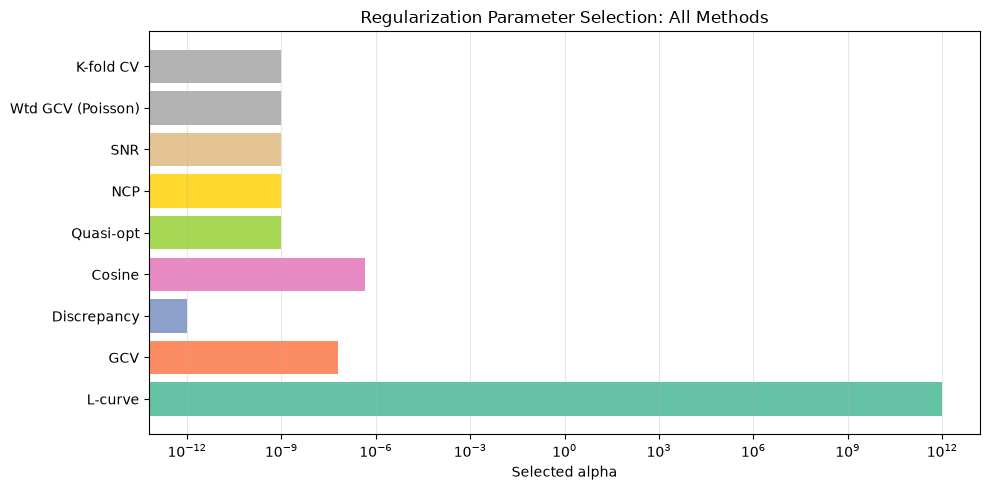

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

names_list = list(alphas.keys())
vals = list(alphas.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(names_list)))

ax.barh(names_list, vals, color=colors)
ax.set_xscale("log")
ax.set_xlabel("Selected alpha")
ax.set_title("Regularization Parameter Selection: All Methods")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Compare unfolded spectra for different alphas

/home/chizhov/python/bssunfold/.venv/lib/python3.12/site-packages/qpsolvers/solvers/osqp_.py:152: UserWarning: OSQP exited with status 'maximum iterations reached'
  warnings.warn(f"OSQP exited with status '{res.info.status}'")
/home/chizhov/python/bssunfold/src/bssunfold/core/unfold_qpsolvers.py:119: UserWarning: Solver 'osqp' did not find a solution.
  warnings.warn(f"Solver '{solver}' did not find a solution.")


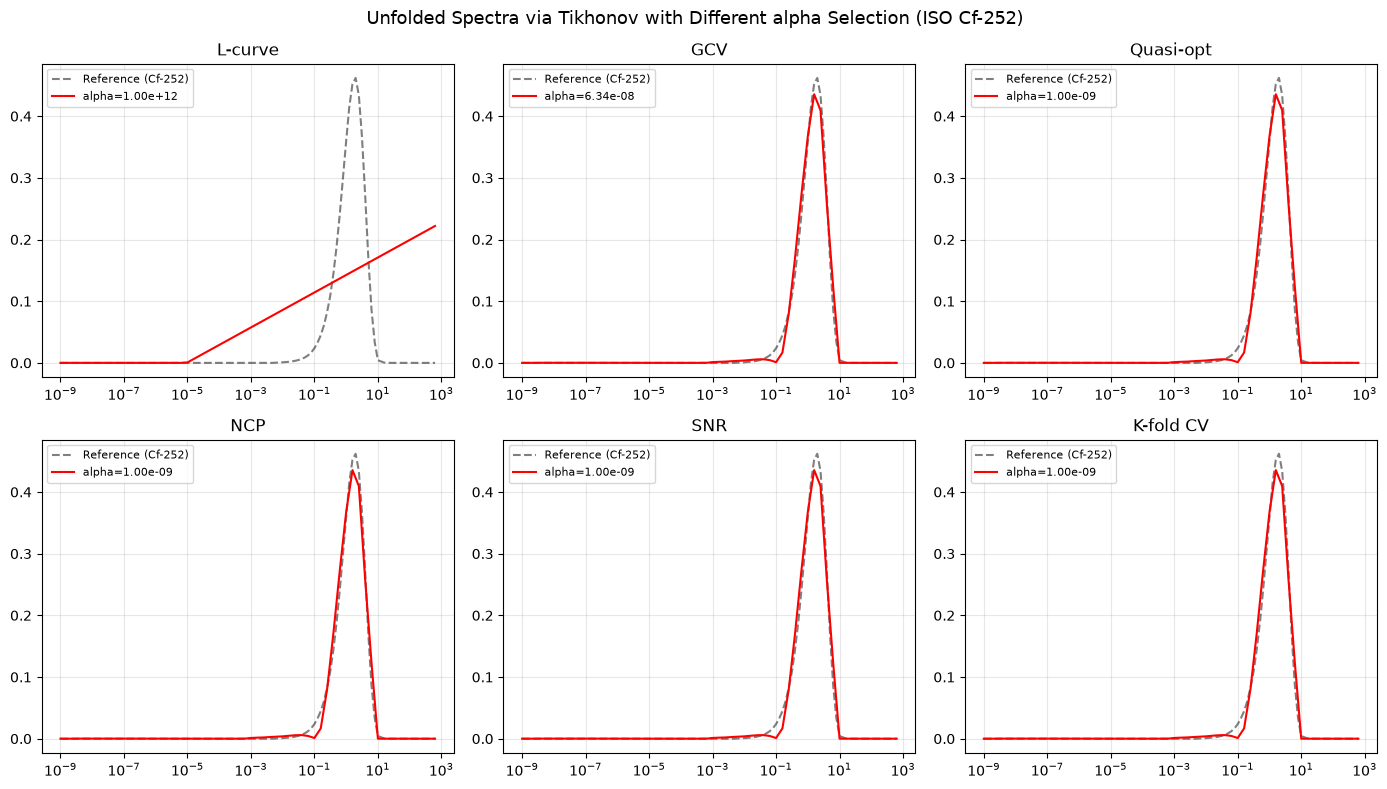

In [5]:
from bssunfold.core._matrix_utils import make_regularization_operator
from bssunfold.core.unfold_qpsolvers import solve_qpsolvers

n = A.shape[1]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

selected_methods = ["L-curve", "GCV", "Quasi-opt", "NCP", "SNR", "K-fold CV"]

for idx, name in enumerate(selected_methods):
    if name not in alphas:
        continue
    alpha = alphas[name]
    try:
        x = solve_qpsolvers(A, b, alpha, norm=2, solver='osqp', smoothness_order=2)
    except Exception:
        x = None
    if x is None:
        # Fallback: unconstrained Tikhonov + non-negativity clip
        L = make_regularization_operator(n, smoothness_order=2)
        ATA = A.T @ A
        ATb = A.T @ b
        LTL = L.T @ L if L is not None else np.zeros((n, n))
        x = np.linalg.solve(ATA + alpha * LTL, ATb)
        x = np.maximum(x, 0)

# Plot reference on original CSV energy grid
    axes[idx].plot(reference_spectrum['E_MeV'], reference_spectrum['ISO_ref_Cf252'],
                   "k--", lw=1.5, alpha=0.5, label="Reference (Cf-252)")
    axes[idx].plot(E, x, "r-", lw=1.5, label=f"alpha={alpha:.2e}")
    axes[idx].set_xscale("log")
    axes[idx].set_yscale("linear")
    axes[idx].set_title(name)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Unfolded Spectra via Tikhonov with Different alpha Selection (ISO Cf-252)", fontsize=13)
plt.tight_layout()
plt.show()

## Use with the Dispatcher

All new criteria are accessible through `select_regularization_parameter`:

In [6]:
for method_name in ["quasi_optimality", "ncp", "snr", "weighted_gcv_poisson", "kfold_cv"]:
    alpha = select_regularization_parameter(A, b, method=method_name)
    print(f"select_regularization_parameter(method={method_name!r:30s})  ->  {alpha:.4e}")

select_regularization_parameter(method='quasi_optimality'            )  ->  1.0000e-09
select_regularization_parameter(method='ncp'                         )  ->  1.0000e-09
select_regularization_parameter(method='snr'                         )  ->  1.0000e-09
select_regularization_parameter(method='weighted_gcv_poisson'        )  ->  1.0000e-09
select_regularization_parameter(method='kfold_cv'                    )  ->  1.0000e-09
